# 1. Import packages

**1. Import packages**

**2. Load and explore data:**
* Read csv files and discritize labels. External dataset can be merged with the compeition dataset (*ADD_EXTERN_DATA == True*).
* Calculate statistical features (mean/std/skew/median/min/max/count) of target values on categorical and bucketized numerical features.
* Configure data spliting strategy for k-fold (*FOLD == k*) training. Spliting can be done with a stratified (*STRAT == True*) or simple K-Fold splitter. As reference for the optional stratification either a calculated multilabel (based on selected features and/or labels) or simply the label can be used (*EXTENDED_STRAT == False*).
* List of dataset columns including data types and number of non-zero elements.
* Show number of unique elements of categorical features.
* Show probability distribution of numerical features.
* Compare probabilty distribution of features and labels between train, validation and test sets (based on a single fold).

**3. Preprocess data:**
* The dataset includes 2 main types of data: numerical features and categorical features.
* Define preprocessing pipelines including an imputing step (for robustness of pipeline, currently there are no missing values in raw data), a transforming step and a scaling step (if necessary).
* Selected preprocessing pipelines will be merged with a ColumnTransformer, possible pipelines are:
    * MinMax/standard/robust scaling of numerical features
    * Logaritmic/square/cube/square root/cube root transformations of numerical features
    * KBins discretization of numerical features
    * Ordinal/onehot encoding of categorical features
    * Principal component analysis (PCA) of numerical features
    * Statistical features (mean/std/skew/median/min/max/count) for categorical and bucketized numerical features
* Model based meta-features can be added (*META_FEAT == True*) with or without PCA on numeric features (*META_PCA*).
* Preprocessed features can be passed into a feature selection model to extract most relevant features (*MAX_FEAT != None*). The maximum number of features can be configured (*MAX_FEAT*).

**4. Define model space for ML methods:**
* Definition of model space with a large number of possible ML methods:
    * Linear models: SGD
    * Support vector machine model: SVC
    * Ensemble models: RandomForest / GradientBoosting / AdaBoost / HistGradientBoosting / XGB / LGBM / CatBoost
    * Other models: KNeighbors
    * Neural network based models: RealMLP
* GPU acceleration can be activated (if supported by choosen ML method(s)) by *GPU_ACC*.

**5. Training:**
* Definition of model parameter sets and tuner interfaces.
* Simple fitting or tuning (*TUNING == True*) of choosen models (*EST_IDS*) on train dataset with K-Fold method. Optionally, different seeds for the folds can be used (*MULTI_SEED == True*).
* Early stopping and the usage of category data type can be configured (*EST_IDS_W_EARLYSTOPPING/EST_IDS_W_CAT_FEAT*).
* Show single balanced accuracy scores for each folds and average balanced accuracy scores for each estimator over the folds during training.

**6. Evaluation:**
* Calculate balanced accuracy scores for each estimators and mean balanced accuracy score over all estimators based on accumulated Out-of-Fold (oof) samples.
* Show feature importances.
* Show balanced accuracy scores of subcategory subsets.
* Show worse balanced accuracy scores of multicategory subsets

**7. Submission:**
* Predict labels and create submission.csv file.
* If more than 1 model have been choosen in EST_IDS (Ensemble solution) then the prediction will be an average of the predictions of the single models.

In [1]:
## Import packages

# General purpose modules
import time
from copy import deepcopy
import warnings
import math
from itertools import combinations

# Data handling and visualization modules
import numpy as np
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns
#import cupy as cp

# Skikit-learn preprocessing and evaluation modules
import sklearn
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import balanced_accuracy_score

# Skikit-learn ML modules
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression

# Further ML modules
import xgboost as xgboost
import lightgbm as lightgbm
import catboost as catboost
import torch
from pytabkit import RealMLP_TD_Classifier

# Show version numbers
print(f'Scikit-learn version: {sklearn.__version__}')
print(f'XGBoost version: {xgboost.__version__}')
print(f'LightGBM version: {lightgbm.__version__}')
print(f'CatBoost version: {catboost.__version__}')

Scikit-learn version: 1.8.0
XGBoost version: 3.2.0
LightGBM version: 4.6.0
CatBoost version: 1.2.10


# 2. Load and explore data

In [2]:
## Read csv files, discritize labels and calculate statistical features

ADD_EXTERN_DATA = True # Extend competition dataset with external dataset

# Read csv files
trainval = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
extern_data = pd.read_csv('/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv')

# Merge data sources
if ADD_EXTERN_DATA:
    trainval = pd.concat([trainval[trainval.columns[1:]], extern_data[trainval.columns[1:]]],
                         ignore_index=True).reset_index(names='id')

# Discretization of labels
target = 'Irrigation_Need'
label_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
reverse_label_mapping = {v: k for k, v in label_mapping.items()}
trainval[target] = trainval[target].replace(label_mapping).astype(np.uint8)

In [3]:
## Basic feature engineering

N_GRAMS = [3] # Choose n-grams to derive
N_GRAMS_EXT = False # Choose whether to extend or replace original catgeorical features with their n-grams
orig_cat_columns = make_column_selector(dtype_include='object')(trainval)

# Create n-grams from categorical columns   
def create_ngrams(df, n_grams=N_GRAMS):
    ngram_columns_dict = {} # Collect and concat the new columns to avoid memory fragmentation issues
    for n in n_grams:
        for ngram in combinations(orig_cat_columns, n):
            ngram_columns_dict[f'{n}gram_'+'_'.join(ngram)] = df[list(ngram)].astype(str).agg('_'.join, axis=1)
    ngram_columns_df = pd.DataFrame(ngram_columns_dict)
    df = pd.concat([df, ngram_columns_df], axis=1)
    return df

trainval = create_ngrams(trainval)
test = create_ngrams(test)

ngram_cat_columns = trainval.filter(like='gram_').columns.tolist()
cat_columns = (orig_cat_columns + ngram_cat_columns) if N_GRAMS_EXT else ngram_cat_columns
print(f'Number of extended categorical features: {len(cat_columns)}')

Number of extended categorical features: 56


In [4]:
## Calculate statistical features of target values on feature groups

STAT_N_BINS = 2040

# Bucketize numerical features
num_columns = make_column_selector(dtype_include='float')(trainval)
bin_num_columns = ['bin_'+col for col in num_columns]
stat_bucket_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
            ('stat_bins', KBinsDiscretizer(n_bins=STAT_N_BINS, strategy='uniform', encode='ordinal', random_state=42))])
trainval[bin_num_columns] = stat_bucket_pipeline.fit_transform(trainval[num_columns]).astype('uint16')
test[bin_num_columns] = stat_bucket_pipeline.transform(test[num_columns]).astype('uint16')

# Create multilabel column
multicat_encoder = LabelEncoder()
strat_cols_eval = ['Mulching_Used', 'Soil_Type', 'Season', 'Crop_Type']
trainval['multicat'] = multicat_encoder.fit_transform(trainval[orig_cat_columns].astype(str).agg('_'.join, axis=1)).astype('uint16')
test['multicat'] = multicat_encoder.transform(test[orig_cat_columns].astype(str).agg('_'.join, axis=1)).astype('uint16')

# Calculate global statistic values as replacement value for unknown groups
df_stat = trainval
global_stats = {'mean': df_stat[target].mean(), 'std': df_stat[target].std(), 'skew': df_stat[target].skew(),
                'median': df_stat[target].median(), 'min': df_stat[target].min(), 'max': df_stat[target].max(), 'count': 0}

# Save statistical features of target values being grouped by feature values
for stat in ['mean', 'std', 'skew', 'median', 'min', 'max', 'count']:
    globals()['stats_' + stat] = {}
for column in cat_columns + bin_num_columns + ['multicat']:
    for stat in ['mean', 'std', 'skew', 'median', 'min', 'max', 'count']:
        globals()['stats_' + stat][column] = (df_stat.groupby(column)[target].agg([stat])/(len(df_stat) if stat=='count' else 1)
                                             ).to_dict()[stat]

In [5]:
## Configure data spliting strategy for k-fold training

STRAT = True # Use stratification for data spliting
EXTENDED_STRAT = True # Stratification is based on multiple features
FOLDS = 10 # Number of folds for k-fold training

# Determine stratification bins
multicat_strat_encoder = LabelEncoder()
strat_cols = ['Mulching_Used', 'Soil_Type', 'Season', 'Crop_Type', target]
trainval['multicat_strat'] = multicat_strat_encoder.fit_transform(trainval[strat_cols].astype(str).agg('_'.join, axis=1)).astype('uint16')

# Merge rare multicats into one category
rare_multicats = trainval['multicat_strat'].value_counts()[trainval['multicat_strat'].value_counts() < FOLDS].index.tolist()
if len(rare_multicats)>0:
    trainval['multicat_strat'] = trainval['multicat_strat'].replace(rare_multicats, rare_multicats[0])

# Experimental data spliting to check spliting quality
skf = (StratifiedKFold if STRAT else KFold)(n_splits=FOLDS, shuffle=True, random_state=333)
train_idx, val_idx = next(skf.split(trainval, trainval['multicat_strat'] if EXTENDED_STRAT else trainval[target]))
train = trainval.iloc[train_idx].reset_index()
val = trainval.iloc[val_idx].reset_index()
trainval_labels = trainval.pop(target)
train_labels = train.pop(target)
val_labels = val.pop(target)

# Verify dataset sizes of first fold
print(f"Total rows:   {len(trainval)}")
print(f"Dev train:    {len(train)} ({len(train)/len(trainval):.2%})")
print(f"Dev valid:    {len(val)} ({len(val)/len(trainval):.2%})")
print(f"Number of unique elements in multicat column: {len(trainval['multicat_strat'].unique())}")
print('-'*80, end='\n\n')

# Size of stratification bins
print(trainval['multicat_strat'].value_counts().tail())
print('-'*80, end='\n\n')
print(trainval['multicat'].value_counts().tail())

Total rows:   640000
Dev train:    576000 (90.00%)
Dev valid:    64000 (10.00%)
Number of unique elements in multicat column: 432
--------------------------------------------------------------------------------

multicat_strat
317    21
386    21
425    20
299    18
407    16
Name: count, dtype: int64
--------------------------------------------------------------------------------

multicat
26735    2
5072     2
44687    2
42566    1
39562    1
Name: count, dtype: int64


List of dataset columns including data types and number of non-zero elements: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576000 entries, 0 to 575999
Data columns (total 90 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   index                                                  576000 non-null  int64  
 1   id                                                     576000 non-null  int64  
 2   Soil_Type                                              576000 non-null  object 
 3   Soil_pH                                                576000 non-null  float64
 4   Soil_Moisture                                          576000 non-null  float64
 5   Organic_Carbon                                         576000 non-null  float64
 6   Electrical_Conductivity                                576000 non-null  float64
 7   Temperature_C                          

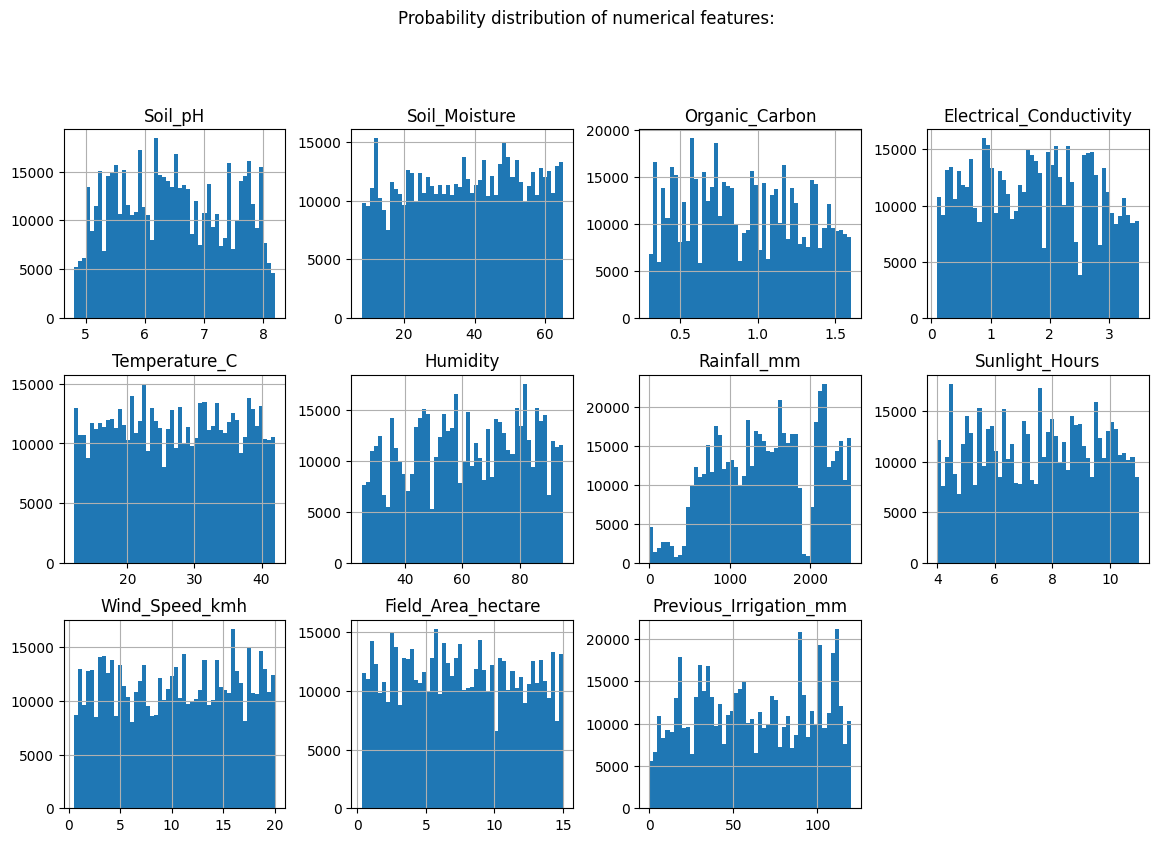

In [6]:
## Explore train dataset

print('List of dataset columns including data types and number of non-zero elements: ', end='\n\n')
train.info()
print('-'*80, end='\n\n')

# Explore categorical features
print('Number of unique elements of categorical features: ', end='\n\n')
for cat in orig_cat_columns:
    print(train[cat].value_counts(), end='\n\n')

# Explore numerical features
train[num_columns].hist(bins=50, figsize=(14,12), layout=(4,4))
plt.suptitle('Probability distribution of numerical features: ')
print('-'*80, end='\n\n')

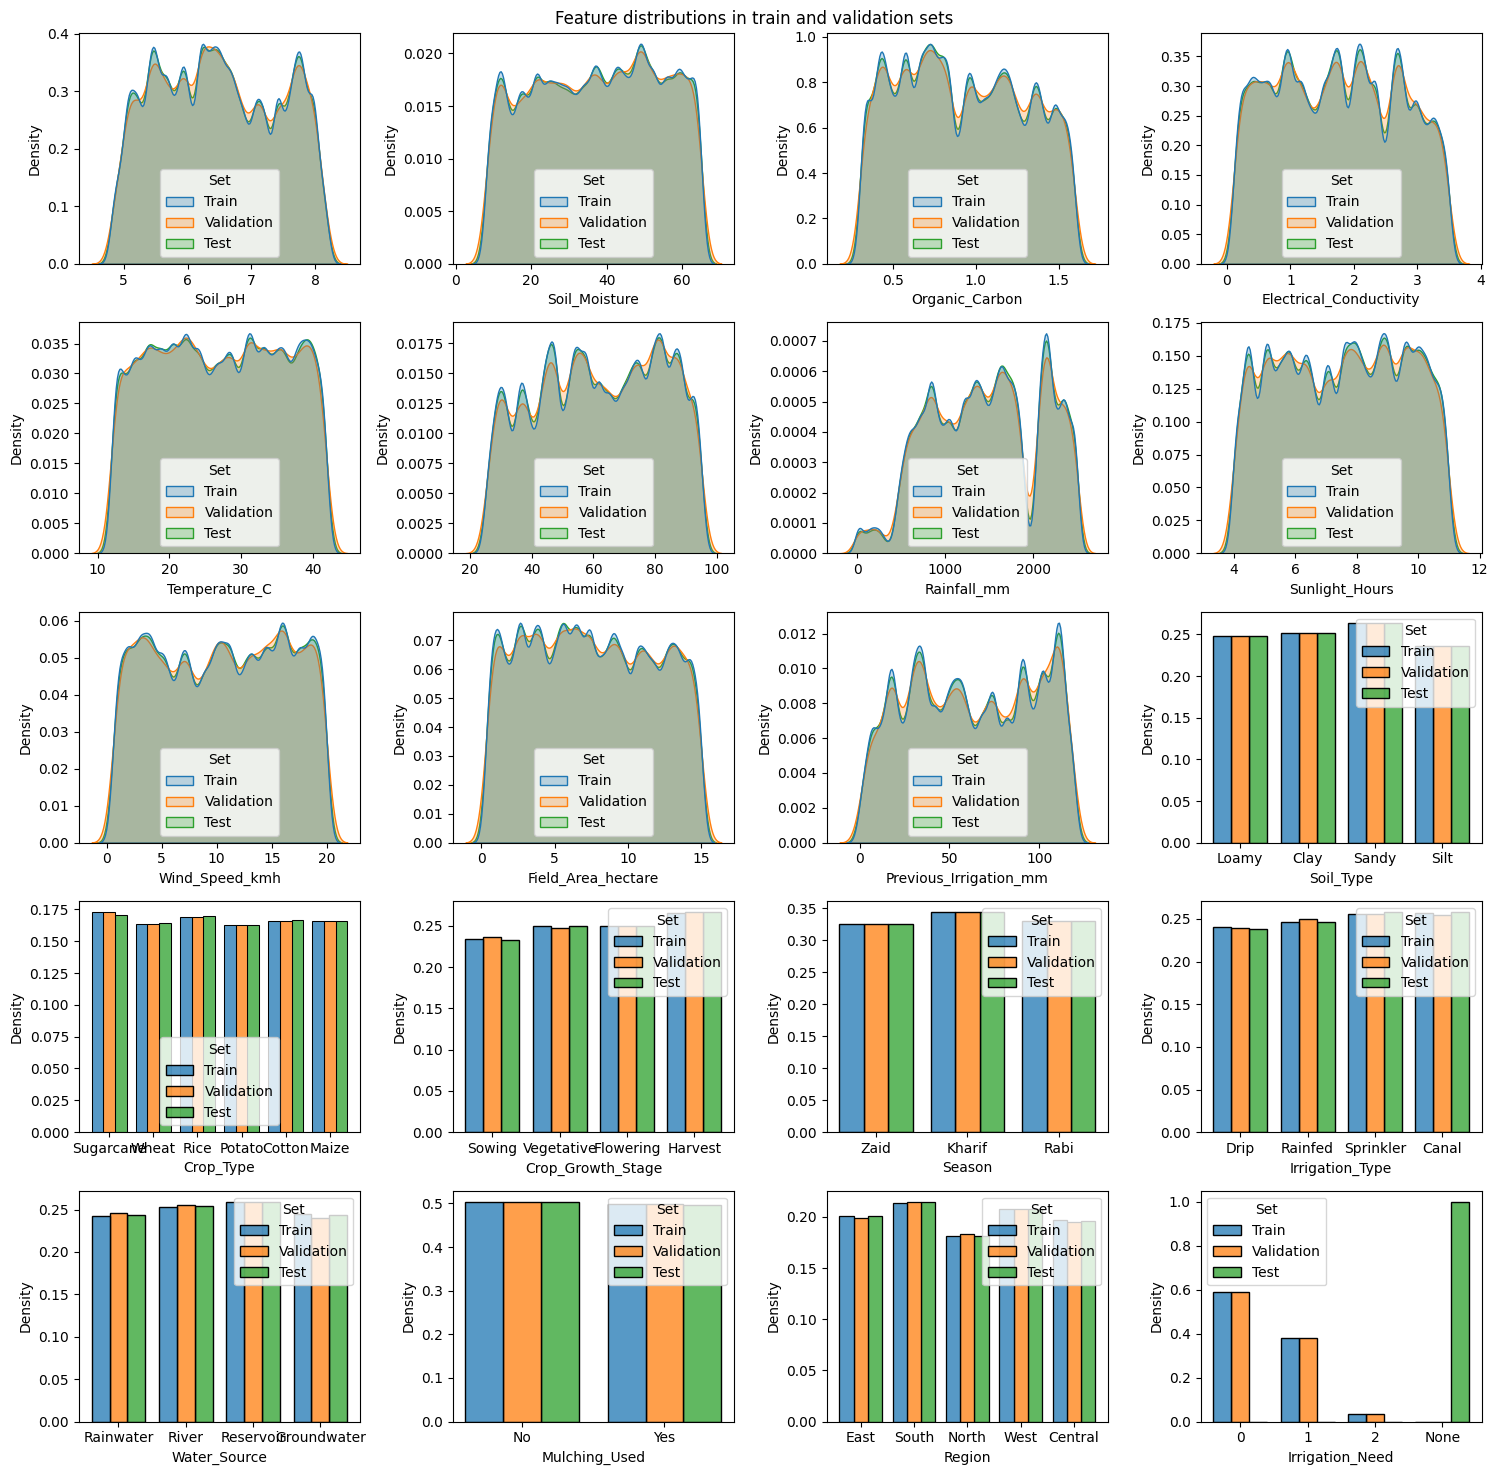

In [7]:
## Compare probabilty distribution of features and labels between train, validation and test sets (based on a single fold)

# Create a dataframe with assigned sources (train/validation/test)
df_plot = pd.concat([train[num_columns+orig_cat_columns].assign(Set='Train'), val[num_columns+orig_cat_columns].assign(Set='Validation'),
                     test[num_columns+orig_cat_columns].assign(Set='Test')])
df_plot.insert(3, value=pd.concat([train_labels, val_labels, pd.Series([None] * len(test), name=target)]), column=target)
df_plot[orig_cat_columns + [target]] = df_plot[orig_cat_columns + [target]].astype('str')
df_plot.reset_index(drop=True, inplace=True)
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn") # Suppress the specific FutureWarning

# Plot probabilty distribution of features
n_cols = 4
n_rows = math.ceil(len(num_columns+orig_cat_columns+[target]) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
fig.suptitle('Feature distributions in train and validation sets')
axes = axes.flatten()
for i, col in enumerate(num_columns):
    sns.kdeplot(data=df_plot, x=col, ax=axes[i], hue='Set', common_norm=False, fill=True)
for j, col in enumerate(orig_cat_columns + [target]):
    sns.histplot(data=df_plot, x=col, ax=axes[i+1+j], hue='Set', bins=len(df_plot[col].unique()),
                 stat='density', discrete=True, multiple="dodge", common_norm=False, shrink=.8)
plt.tight_layout()
plt.show()
del df_plot

# 3. Preprocess data

In [8]:
## Helping function for adding statistical features

def target_stats(X, features, st_type, global_stats=global_stats):
    stats = globals()['stats_' + st_type]
    X_stat = pd.DataFrame()
    for c in features:
        X_stat[c] = X[c].map(stats[c]).fillna(global_stats[st_type])
    return X_stat

In [9]:
## Define pipelines

# Pipelines for numerical features
minmax_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                            ('minmax_scaling', MinMaxScaler())])
log_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                         ('log_trans', FunctionTransformer(func=lambda x: np.log(x+0.001), feature_names_out='one-to-one')),
                         ('minmax_scaling', MinMaxScaler())])
square_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                            ('square_trans', FunctionTransformer(func=np.square, feature_names_out='one-to-one')),
                            ('minmax_scaling', MinMaxScaler())])
cube_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                          ('cube_trans', FunctionTransformer(func=lambda x: np.power(x, 3), feature_names_out='one-to-one')),
                          ('minmax_scaling', MinMaxScaler())])
sqrt_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                          ('sqrt_trans', FunctionTransformer(func=np.sqrt, feature_names_out='one-to-one')),
                          ('minmax_scaling', MinMaxScaler())])
cbrt_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                          ('cbrt_trans', FunctionTransformer(func=np.cbrt, feature_names_out='one-to-one')),
                          ('minmax_scaling', MinMaxScaler())])
kbins_pipeline = Pipeline([('imputer', SimpleImputer(strategy="median")),
                           ('kbins', KBinsDiscretizer(n_bins=2040, strategy='uniform', encode='ordinal', random_state=42)),
                           ('kbins_cast', FunctionTransformer(lambda X: X.astype(np.uint8), feature_names_out='one-to-one'))])

# Pipelines for categorical features
ordinal_pipeline = Pipeline([('imputer', SimpleImputer(strategy="most_frequent")),
                             ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.int8))])
onehot_pipeline = Pipeline([('imputer', SimpleImputer(strategy="most_frequent")),
                            ('onehot', OneHotEncoder(sparse_output=False))])

# Pipelines for statistical features
mean_pipeline = Pipeline([('mean', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'mean'), feature_names_out='one-to-one'))])
std_pipeline = Pipeline([('std', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'std'), feature_names_out='one-to-one'))])
skew_pipeline = Pipeline([('skew', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'skew'), feature_names_out='one-to-one'))])
median_pipeline = Pipeline([('median', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'median'), feature_names_out='one-to-one'))])
min_pipeline = Pipeline([('min', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'min'), feature_names_out='one-to-one'))])
max_pipeline = Pipeline([('max', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'max'), feature_names_out='one-to-one'))])
frq_pipeline = Pipeline([('frq', FunctionTransformer(func=lambda x: target_stats(x, x.columns, 'count'), feature_names_out='one-to-one'))])

# Pipeline for target encoding
te_pipeline = Pipeline([('te', TargetEncoder(cv=7, shuffle=True, smooth='auto', target_type='multiclass', random_state=42))])

# Pipeline for PCA/LDA on non-linear transformations of numerical features
nonlinear_transformer = ColumnTransformer([("scaled", minmax_pipeline, num_columns),
                                           ("log", log_pipeline, num_columns),
                                           ("square", square_pipeline, num_columns),
                                           ("cube", cube_pipeline, num_columns),
                                           ("sqrt", log_pipeline, num_columns),
                                           ("cbrt", square_pipeline, num_columns)
                                          ])
pca_pipeline = Pipeline([('nonlinear', nonlinear_transformer), ('pca', PCA(random_state=42))])
lda_pipeline = Pipeline([('nonlinear', nonlinear_transformer), ('lda', LinearDiscriminantAnalysis(n_components=2))])

In [10]:
## Deinfe preprocessing pipeline and fit preprocessing

# Preprocessing pipeline
preprocessing = ColumnTransformer([## Numerical transformations
                                   ("scaled", minmax_pipeline, num_columns),
                                   #("nonlin", nonlinear_transformer, num_columns),
                                   #("pca", pca_pipeline, num_columns),
                                   #("lda", lda_pipeline, num_columns),
                                   #("cluster", kbins_pipeline, num_columns),

                                   ## Categorical encoding
                                   ("ordinal", ordinal_pipeline, cat_columns),
                                   #("onehot", onehot_pipeline, cat_columns),
                                   
                                   ## Statistical transformers
                                   ("mean", mean_pipeline, bin_num_columns+cat_columns),
                                   ("std", std_pipeline, bin_num_columns+cat_columns),
                                   ("skew", skew_pipeline, bin_num_columns+cat_columns),
                                   ("median", median_pipeline, bin_num_columns+cat_columns),
                                   ("min", min_pipeline, bin_num_columns+cat_columns),
                                   ("max", max_pipeline, bin_num_columns+cat_columns),
                                   ("frq", frq_pipeline, bin_num_columns+cat_columns),
                                   ("te", te_pipeline, bin_num_columns+cat_columns),
                                  ]).set_output(transform='pandas')

# Preprocess data
train_prepared = preprocessing.fit_transform(trainval, trainval_labels.astype('str'))
test_prepared = preprocessing.transform(test)
train_labels = trainval_labels
train = trainval
print(f'Number of unfiltered features: {train_prepared.shape[1]}')

Number of unfiltered features: 737


In [11]:
## Final feature selection based on XGBoost feature importances

GPU_ACC = True
MAX_FEAT = train_prepared.shape[1] # Max number of features after feature selection

if MAX_FEAT:
    # Define base model for feature selection
    xgbr_fs = xgboost.XGBClassifier(device ='gpu' if GPU_ACC else 'cpu', random_state=42, enable_categorical=True)
    catc_fs = catboost.CatBoostClassifier(loss_function='MultiClass', eval_metric='Accuracy', auto_class_weights='Balanced',
                                         random_state=42, task_type='GPU' if GPU_ACC else 'CPU', verbose=False)
    model_fs = SelectFromModel(catc_fs, max_features=MAX_FEAT, threshold=1e-8, prefit=False
                              ).set_output(transform="pandas").fit(train_prepared, train_labels)
    # Perform feature selection with choosen model
    train_prepared = model_fs.transform(train_prepared)
    test_prepared = model_fs.transform(test_prepared)
print(f'Number of selected features: {train_prepared.shape[1]}')

Number of selected features: 528


In [12]:
## Calculate model based meta-features with linear models

META_FEAT = False # Add model based meta features
META_PCA = False # Use PCA for calculating model based meta features

if META_FEAT:
    preprocessing_meta = ColumnTransformer([("pca", pca_pipeline, num_columns) if META_PCA else (
                                                'nonlinear', nonlinear_transformer, num_columns),
                                            ("onehot", onehot_pipeline, cat_columns)]).set_output(transform='pandas')
    train_meta = preprocessing_meta.fit_transform(train)
    val_meta = preprocessing_meta.transform(val)
    test_meta = preprocessing_meta.transform(test)
    print(f'Number of unfiltered features for meta feature learning: {train_meta.shape[1]}')
    
    lr_meta = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(train_meta, train_labels)
    sgdc_meta = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42).fit(train_meta, train_labels)
    
    train_prepared['lr_meta'] = lr_meta.predict(train_meta)
    train_prepared['sgdc_meta'] = sgdc_meta.predict(train_meta)
    test_prepared['lr_meta'] = lr_meta.predict(test_meta)
    test_prepared['sgdc_meta'] = sgdc_meta.predict(test_meta)
    print(f'Number of unfiltered features including meta features: {train_prepared.shape[1]}')

# 4. Define model space for ML methods

In [13]:
## Helping function to create parameter grids

def make_param(param_dict, model='est'):
    for elem in param_dict.copy():
        if elem == 'n_components':
            param_dict['pca'+'__'+elem] = param_dict.pop(elem)
        else:
            param_dict[model+'__'+elem] = param_dict.pop(elem)
    return param_dict

In [14]:
## Machine learning models and their hyperparameter search space

# Models
svc = SVC(kernel='linear', class_weight='balanced')
rfc = RandomForestClassifier(random_state=42)
kneigh = KNeighborsClassifier()
gbc = GradientBoostingClassifier(random_state=42)
xgb = xgboost.XGBClassifier(objective='multi:softmax', eval_metric='merror', num_class=len(label_mapping),
                            enable_categorical=True, device='cuda' if GPU_ACC else 'cpu', random_state=42)
ada = AdaBoostClassifier(random_state=42)
hgbc = HistGradientBoostingClassifier(scoring='balanced_accuracy', class_weight='balanced', random_state=42)
lgbm = lightgbm.LGBMClassifier(objective='multiclass', metric='multi_error', is_unbalance=True, random_state=42,
                               device ='gpu' if GPU_ACC else 'cpu', verbosity=-1)
catc = catboost.CatBoostClassifier(loss_function='MultiClass', eval_metric='Accuracy', auto_class_weights='Balanced',
                                   random_state=42, task_type='GPU' if GPU_ACC else 'CPU', verbose=False)
sgdc = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
rmlp = RealMLP_TD_Classifier(device='cuda' if GPU_ACC else 'cpu', random_state=42, verbosity=2)

# Model space
EstimatorStr = {1: 'svc', 2: 'rfc', 3: 'kneigh', 4: 'gbc', 5: 'xgb', 6: 'ada',
                7: 'hgbc', 8: 'lgbm', 9: 'catc', 10: 'sgdc', 11: 'rmlp'}
EstimatorMdl = {1: svc, 2: rfc, 3: kneigh, 4: gbc, 5: xgb, 6: ada, 7: hgbc, 8: lgbm, 9: catc, 10: sgdc, 11: rmlp}

In [15]:
## Tuned hyperparameter sets

# svc parameter
param_single_svc = make_param({}) #
# rfc parameter
param_single_rfc = make_param({}) # 
# kneight parameter
param_single_kneigh = make_param({}) # 
# gbc parameter
param_single_gbc = make_param({}) # 
# xgb parameter
param_single_xgb = make_param({'n_estimators': 20000, 'learning_rate': 0.02, 'max_depth': 6, 'early_stopping_rounds': 500,
                               #'subsample': 0.8, 'colsample_bytree': 0.8,
                               #'reg_alpha': 0.1, 'reg_lambda': 1.0, 'gamma': 0.05, 'min_child_weight': 5
                               }) # 
# ada parameter
param_single_ada = make_param({}) # 
# hgbc parameter
param_single_hgbc = make_param({#'max_iter': 2000, 'learning_rate': 0.1, 'max_depth': 12, 'n_iter_no_change': 10
                                }) # 
# lgbm parameter
param_single_lgbm = make_param({'n_estimators': 2000, 'learning_rate': 0.1, 'max_depth': 6, 'early_stopping_rounds': 100,
                                #'subsample': 0.8, 'colsample_bytree': 0.8, 'num_leaves': 31,
                                }) # 
# catc parameter
param_single_catc = make_param({'n_estimators': 20000, 'learning_rate': 0.1, 'max_depth': 5, 'early_stopping_rounds': 150,
                                'max_bin': 2040, 'l2_leaf_reg': 6, 'bagging_temperature': 1.0
                                }) #
# sgdc parameter
param_single_sgdc = make_param({}) #
# rmlp parameter
param_single_rmlp = make_param({}) #

In [16]:
## Hyperparameter sets for parameter tuning

# xgb parameter
param_grid_xgb = make_param({'n_estimators': [50000],
                             'early_stopping_rounds': [100],
                             'max_depth': [3, 4, 5],
                             'learning_rate': [0.05],
                             'subsample': [0.8, 1.0],
                             'colsample_bytree': [0.8, 1.0],
                             'reg_lambda': [0.1, 1, 10],
                             #'reg_alpha': [0.1, 1, 10],
                             })
# hgbc parameter
param_grid_hgbc = make_param({#'max_depth': [6, 12, 18, 24],
                              #'learning_rate': [0.01, 0.03, 0.1],
                              #'max_bins': [200,255,300],
                              'max_iter': [1000],
                              'n_iter_no_change': [10, 20, 40, 80, 160]
                              })
# lgbm parameter
param_grid_lgbm = make_param({#'n_estimators': [100,200,300],
                              'num_leaves': [80,110,120,125,130,135,140,150,180],
                              'max_depth': [24,29,31,32,33,35,40],
                              'learning_rate': [0.05,0.1,0.2],
                              })
# catc parameter
param_grid_catc = make_param({'n_estimators': [20000], # 4000, 6000, 8000, 10000
                              'learning_rate': [0.05, 0.1], # 0.005, 0.01, 0.03, 0.05, 0.1
                              'max_depth': [5], #
                              'early_stopping_rounds': [100,150,200],
                              'l2_leaf_reg': [30,50,100],
                              'bagging_temperature': [0.0, 0.1, 0.2]
                              #'random_state': [0,1,2,3,4,5,6,7,8,9,10]
                              })

# 5. Training

In [17]:
## Single fitting with tuned parameters or grid search for machine learning methods

TUNING = False # Choose between single fitting or parameter tuning
EST_IDS = [9] # Choose model(s) {1: 'svc', 2: 'rfc', 3: 'kneigh', 4: 'gbc', 5: 'xgb', 6: 'ada', 7: 'hgbc', 8: 'lgbm', 9: 'catc', 10: 'sgdc'}
EST_IDS_W_EARLYSTOPPING = [5,7,8,9,11]
EST_IDS_W_CAT_FEAT = [5,7,8,9,11]
MULTI_SEED = False
val_preds = pd.DataFrame(train_labels)
test_pred = pd.DataFrame()
test_probs = []

for est_id in EST_IDS:
    start_time = time.time()
    bal_acc_train_ls = []
    bal_acc_val_ls = []
    
    # Define pipeline
    pipeline = Pipeline([('est', EstimatorMdl[est_id])])

    # Cross-validation configuration w/wo extended stratification
    cv_gen = skf.split(train_prepared, train['multicat_strat'] if EXTENDED_STRAT else train_labels)

    # Cast categorical features to 'category' for choosen estimators being able to handle it
    cat_feat = make_column_selector(pattern='ordinal|cluster|onehot')(train_prepared)
    train_prepared[cat_feat] = train_prepared[cat_feat].astype(str).astype('category' if est_id in EST_IDS_W_CAT_FEAT else 'uint8')
    test_prepared[cat_feat] = test_prepared[cat_feat].astype(str).astype('category' if est_id in EST_IDS_W_CAT_FEAT else 'uint8')
    catc.set_params(cat_features=cat_feat if est_id in EST_IDS_W_CAT_FEAT else None)
    
    # Fitting or tuning on train dataset with k-fold cross-validation
    param = globals()[f'param_grid_{EstimatorStr[est_id]}' if TUNING else f'param_single_{EstimatorStr[est_id]}']
    if TUNING:
        eval_set = {}
        if est_id in EST_IDS_W_EARLYSTOPPING:
            # Split data into train and validation set and set configuration parameters if early stopping configured
            sss = (StratifiedShuffleSplit if STRAT else ShuffleSplit)(n_splits=1, test_size=0.1, random_state=42)
            train_index, eval_index = next(sss.split(train, train['multicat_strat'] if EXTENDED_STRAT else train_labels))
            X_train, X_eval = train_prepared.iloc[train_index], train_prepared.iloc[eval_index]
            train_multi = train['multicat_strat'].iloc[train_index]
            y_train, y_eval = train_labels.iloc[train_index], train_labels.iloc[eval_index]
            eval_set['est__eval_set'] = [(X_eval, np.array(y_eval))]
            if est_id==5: eval_set['est__verbose'] = 0
            cv_gen = skf.split(X_train, y_train if EXTENDED_STRAT else y_train)
        else:
            X_train, y_train = train_prepared, train_labels

        # Tune model
        grid = GridSearchCV(pipeline, param, scoring='balanced_accuracy', verbose=3, cv=cv_gen)
        grid.fit(X_train, np.array(y_train), **eval_set)
        print(grid.best_params_)
        print(grid.cv_results_)
        pipeline_tune = grid.best_estimator_

        # Store predictions and model
        val_preds.loc[eval_index, f'pred_{EstimatorStr[est_id]}'] = pipeline_tune.predict(X_eval)
        val_preds = val_preds.dropna()
        test_pred[f'pred_{EstimatorStr[est_id]}'] = pipeline_tune.predict(test_prepared)
        globals()[f'model1_{EstimatorStr[est_id]}'] = pipeline_tune
    else:
        # Training with k-fold cross-validation
        for i, (train_index, eval_index) in enumerate(cv_gen):
            # Split data into train and validation set
            X_train, X_eval = train_prepared.iloc[train_index], train_prepared.iloc[eval_index]
            y_train, y_eval = train_labels.iloc[train_index], train_labels.iloc[eval_index]

            # Clone selected pipeline, set configuration parameters and train model
            pipeline_train = deepcopy(pipeline)
            pipeline_train.set_params(**param)
            if MULTI_SEED:
                pipeline_train.set_params(est__random_state=(42+1*i))  
            eval_set = {}
            if est_id in EST_IDS_W_EARLYSTOPPING:
                if (est_id==7) | (est_id==11):
                    eval_set['est__X_val'], eval_set['est__y_val'] = X_eval, np.array(y_eval)
                else:
                    eval_set['est__eval_set'] = [(X_eval, np.array(y_eval))]
                if est_id==5:
                    eval_set['est__verbose'] = 0
            pipeline_train.fit(X_train, np.array(y_train), **eval_set)

            # Calculate and show balanced accuracy scores after training of each fold
            train_score = balanced_accuracy_score(np.array(y_train), pipeline_train.predict(X_train))
            eval_preds = pipeline_train.predict(X_eval)
            val_score = balanced_accuracy_score(np.array(y_eval), eval_preds)
            
            # Store oof predictions and the scores for each fold
            val_preds.loc[eval_index, f'pred_{EstimatorStr[est_id]}'] = eval_preds
            bal_acc_train_ls.append(train_score)
            bal_acc_val_ls.append(val_score)

            # Store predictions for test set
            test_pred[f'pred{i+1}_{EstimatorStr[est_id]}'] = pipeline_train.predict(test_prepared).ravel()
            test_probs.append(pipeline_train.predict_proba(test_prepared))
                                                           
            # Save trained pipeline
            globals()[f'model{i+1}_{EstimatorStr[est_id]}'] = pipeline_train
            
            print(f'Estimator: {EstimatorStr[est_id]} of fold {i+1} is fitted')
            print(f'Train balanced accuracy score: {train_score}')
            print(f'Val balanced accuracy score: {val_score}')
            print(f'Elapsed time: {int(time.time() - start_time)} [s]')
            print('-'*40)

        print(f'Average train balanced accuracy score of {EstimatorStr[est_id]} estimator over all folds: {sum(bal_acc_train_ls)/len(bal_acc_train_ls)}')
        print(f'Average val balanced accuracy score of {EstimatorStr[est_id]} estimator over all folds: {sum(bal_acc_val_ls)/len(bal_acc_val_ls)}')
        print('-'*80)
        print('-'*80)

Estimator: catc of fold 1 is fitted
Train balanced accuracy score: 0.9832789115635729
Val balanced accuracy score: 0.9802126845438429
Elapsed time: 61 [s]
----------------------------------------
Estimator: catc of fold 2 is fitted
Train balanced accuracy score: 0.9867264112660191
Val balanced accuracy score: 0.9819720608202357
Elapsed time: 133 [s]
----------------------------------------
Estimator: catc of fold 3 is fitted
Train balanced accuracy score: 0.985223669708387
Val balanced accuracy score: 0.982313709828592
Elapsed time: 196 [s]
----------------------------------------
Estimator: catc of fold 4 is fitted
Train balanced accuracy score: 0.985077134649714
Val balanced accuracy score: 0.9827369604604909
Elapsed time: 259 [s]
----------------------------------------
Estimator: catc of fold 5 is fitted
Train balanced accuracy score: 0.9844087374654285
Val balanced accuracy score: 0.9811355355667007
Elapsed time: 317 [s]
----------------------------------------
Estimator: catc of 

# 6. Evaluation

In [18]:
## Calculate balanced accuracy scores for each estimators and mean balanced accuracy score over all estimators based on accumulated Out-of-Fold (oof) samples

# Balanced accuracy scores for each estimator based on accumulated oof samples
for est_id in EST_IDS:
    est_oof_score = balanced_accuracy_score(val_preds[target], val_preds[f'pred_{EstimatorStr[est_id]}'])
    print(f'Balanced accuracy score over all oof samples for {EstimatorStr[est_id]} estimator: {est_oof_score}')
    print('-'*80)

# Balanced accuracy score on mean value of ensemble predictions based on accumulated oof samples
val_preds['pred_score'] = val_preds.filter(like='pred').mean(axis=1).round().astype(np.uint8)
overall_oof_score = balanced_accuracy_score(val_preds[target], val_preds['pred_score'])
print(f'Overall balanced accuracy score over all oof samples and all estimators: {overall_oof_score}')
print('-'*80)
print('Show predictions and labels of validation dataset: ')
print(val_preds)

Balanced accuracy score over all oof samples for catc estimator: 0.9808999804554688
--------------------------------------------------------------------------------
Overall balanced accuracy score over all oof samples and all estimators: 0.9808999804554688
--------------------------------------------------------------------------------
Show predictions and labels of validation dataset: 
        Irrigation_Need  pred_catc  pred_score
0                     0        0.0           0
1                     0        0.0           0
2                     0        0.0           0
3                     1        1.0           1
4                     0        0.0           0
...                 ...        ...         ...
639995                0        0.0           0
639996                0        0.0           0
639997                0        0.0           0
639998                0        0.0           0
639999                1        2.0           2

[640000 rows x 3 columns]


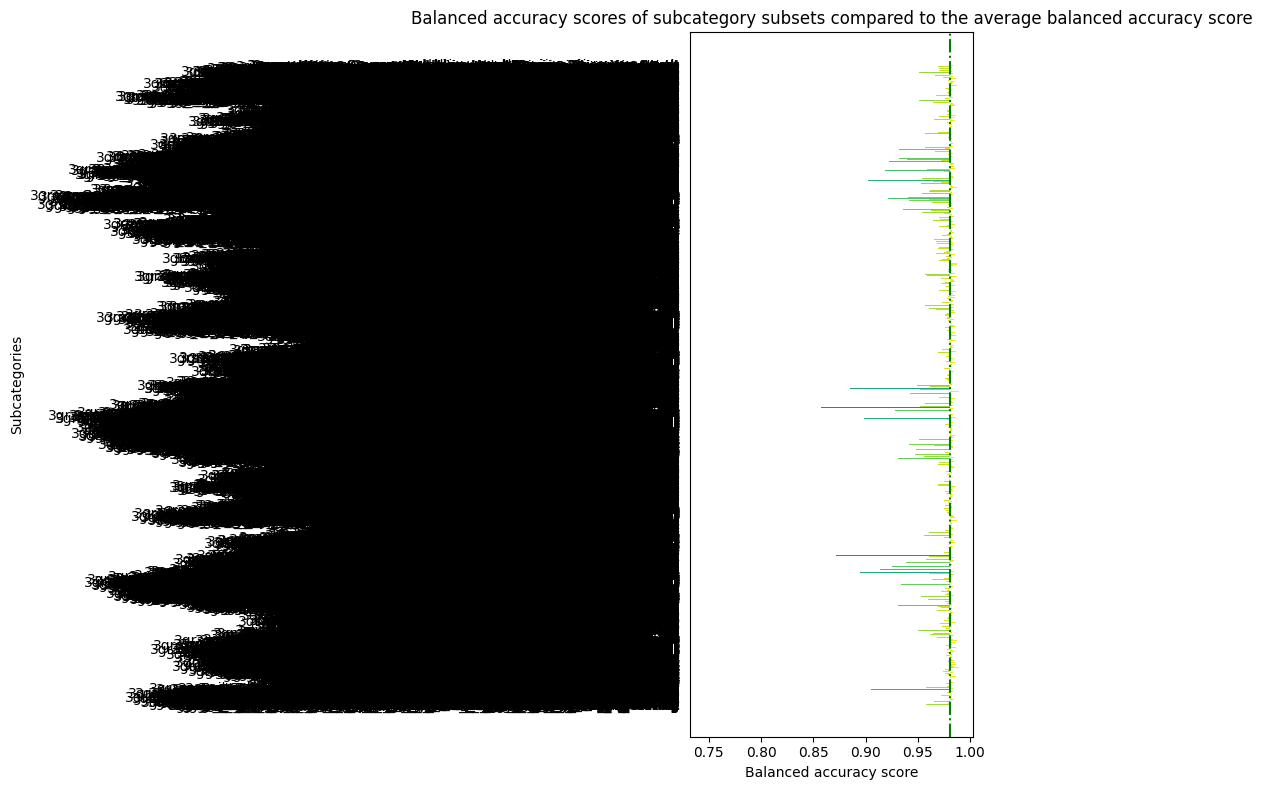

In [19]:
## Show balanced accuracy scores of subcategory subsets

subcats = []
subcat_bal_acc_scores  = []
for cat in cat_columns:
    for subcat in np.sort(train[cat].unique()):
        subcats.append(cat+'_'+str(subcat))
        val_filtered = val_preds[target][train[cat] == subcat]
        val_labels_filtered = val_preds['pred_score'][train[cat] == subcat]
        subcat_bal_acc_scores.append(balanced_accuracy_score(val_filtered, val_labels_filtered))

# Create bar chart
fig1, ax1 = plt.subplots(figsize=(10, 8))
cmap = plt.get_cmap('viridis')
rescale = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x))
normalized_values = rescale(subcat_bal_acc_scores)
ax1.barh(subcats, np.array(subcat_bal_acc_scores)-overall_oof_score, color=cmap(normalized_values), left=overall_oof_score)
plt.title(f'Balanced accuracy scores of subcategory subsets compared to the average balanced accuracy score')
plt.xlabel('Balanced accuracy score')
plt.ylabel('Subcategories')
ax1.axvline(x=overall_oof_score, color='green', linestyle='-.')
plt.tight_layout()
ax1.tick_params(left=False, bottom=True)

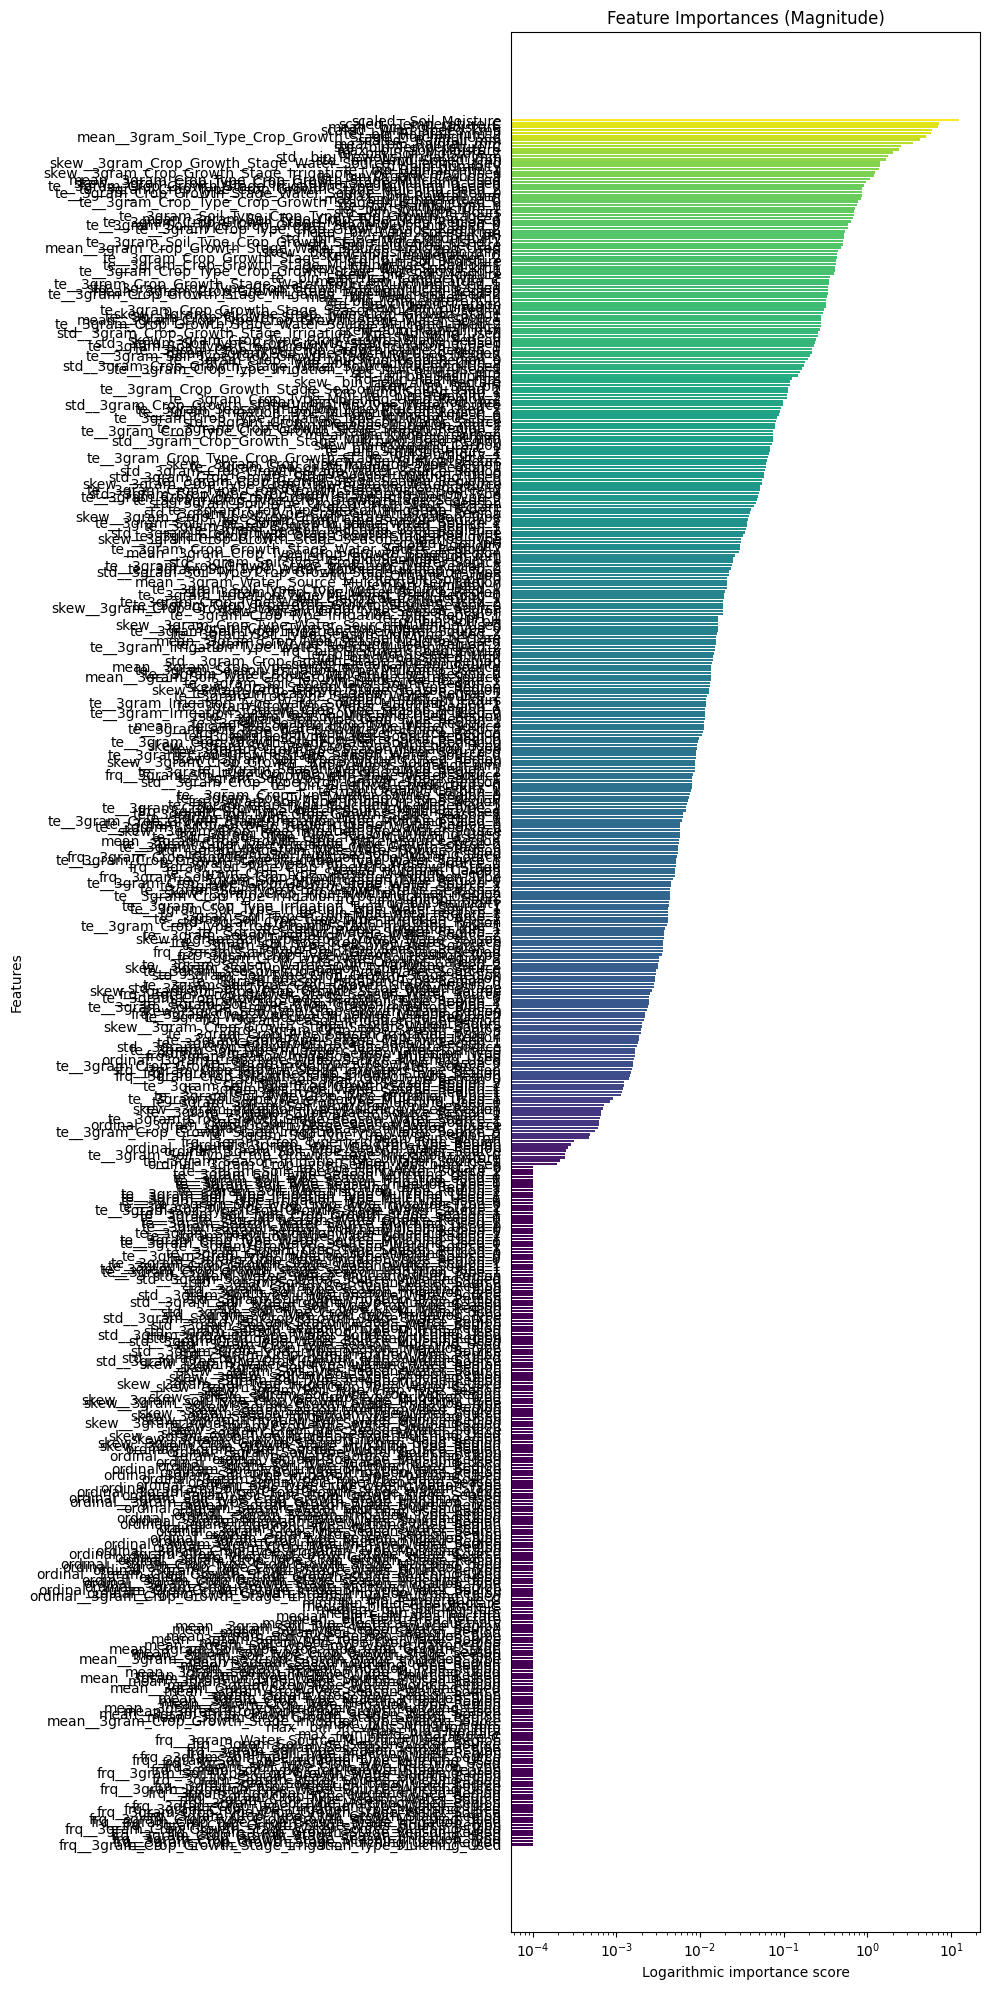

In [20]:
## Show feature importances

if est_id in [5, 8, 9]:
    # Sort feature names and their importances
    categories = train_prepared.columns
    values = globals()[f'model1_{EstimatorStr[est_id]}'][-1].feature_importances_+1e-4
    sorted_values, sorted_categories = zip(*sorted(zip(values,categories), reverse=False))
    
    # Plot feature importances
    fig3, ax3 = plt.subplots(figsize=(10, 20))
    normalized_values = rescale(np.log(sorted_values))
    ax3.barh(sorted_categories, sorted_values, color=cmap(normalized_values), log=True)
    plt.title(f'Feature Importances (Magnitude)')
    plt.xlabel('Logarithmic importance score')
    plt.ylabel('Features')
    plt.tight_layout()
    ax3.tick_params(left=False, bottom=True)

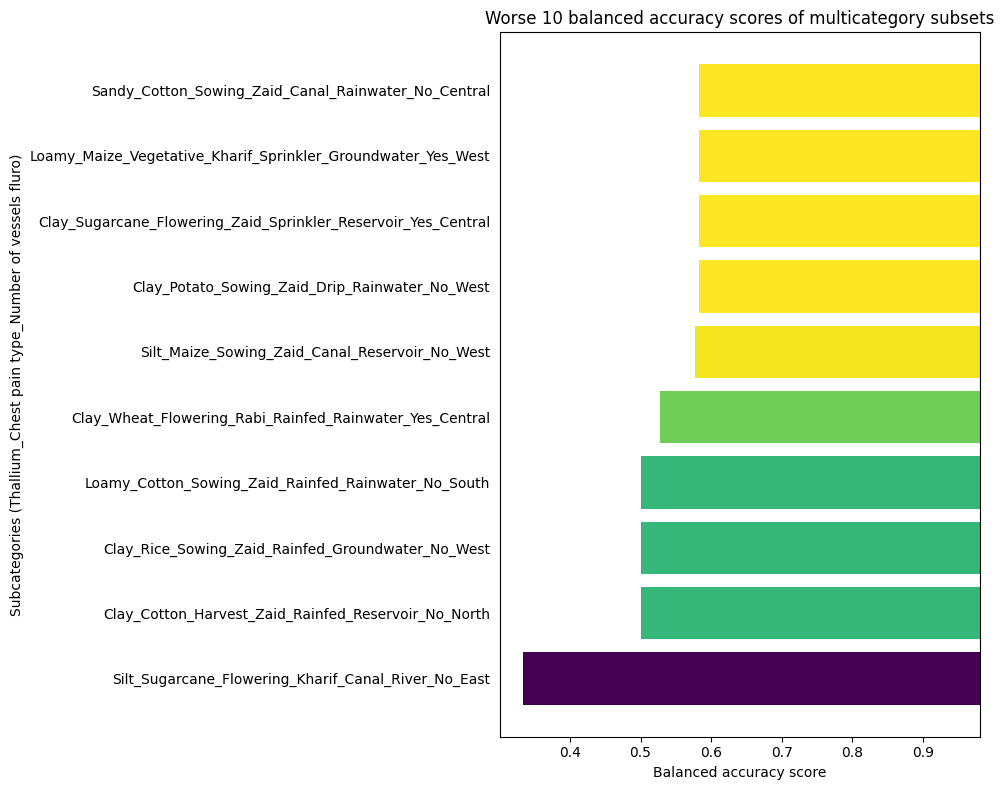

In [21]:
## Show worse balanced accuracy scores of multicategory subsets

if not TUNING:
    multicats = []
    multicat_bal_acc_scores = []
    for multicat in train['multicat'].unique():
        if train_labels[train['multicat'] == multicat].nunique() == len(label_mapping):
            multicats.append(multicat)
            val_filtered = val_preds[target][train['multicat'] == multicat]
            val_labels_filtered = val_preds['pred_score'][train['multicat'] == multicat]
            multicat_bal_acc_scores.append(balanced_accuracy_score(val_filtered, val_labels_filtered))
    multicats = multicat_encoder.inverse_transform(multicats)
    sorted_multicat_bal_acc_scores, sorted_multicats = zip(*sorted(zip(multicat_bal_acc_scores, multicats), reverse=False))
    
    # Create bar chart
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    n_top = 10
    cmap = plt.get_cmap('viridis')
    rescale = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x))
    normalized_values = rescale(sorted_multicat_bal_acc_scores[:n_top])
    ax2.barh(sorted_multicats[:n_top], np.array(sorted_multicat_bal_acc_scores[:n_top])-overall_oof_score,
             color=cmap(normalized_values), left=overall_oof_score)
    plt.title(f'Worse {n_top} balanced accuracy scores of multicategory subsets')
    plt.xlabel('Balanced accuracy score')
    plt.ylabel('Subcategories (Thallium_Chest pain type_Number of vessels fluro)')
    plt.tight_layout()
    ax2.tick_params(left=False, bottom=True)

# 7. Submission

In [22]:
## Test prediction & submission 

submission_df = test[['id']].copy()

# Take the mean value of prediction over all estimators and folds
#submission_df[target] = pd.DataFrame(np.stack(test_probs).mean(axis=0).argmax(axis=-1)).replace(reverse_label_mapping)
submission_df[target] = test_pred.mean(axis=1).round().astype(np.uint8).replace(reverse_label_mapping)

# Write dataframe to .csv file
submission_df.to_csv("submission.csv", index=False)
print("✅ submission.csv saved!")
submission_df

✅ submission.csv saved!


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low
